# Predictive Significance Analysis

Ranks the 6 candidate features by predictive power using three complementary methods:

1. **Pearson r** — linear correlation with the binary label (baseline, already seen in EDA)
2. **Mutual Information** — non-linear, model-free association
3. **Random Forest Permutation Importance** — model-based, captures interactions; scored by ROC-AUC drop

Each method is applied at all valid `t` values (`t ∈ {0, 7, 30}`) per feature.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
os.makedirs('output/predictive_significance', exist_ok=True)

T_VALUES    = [0, 7, 30]
RANDOM_STATE = 42
COL_POS     = '#E07B54'
COL_NEG     = '#5B8DB8'

In [2]:
subs   = pd.read_csv('data/features_submissions.csv', parse_dates=['createdDate', 'resolvedDate'])
events = pd.read_csv('data/features_events.csv',      parse_dates=['event_date'])
print(f'Submissions: {len(subs)} | Events: {len(events)}')

Submissions: 881 | Events: 17211


---
## Feature Matrix Builder

Vectorised equivalent of the per-submission functions in `src/features.py`,
used here for batch computation across all submissions.

In [3]:
def build_feature_matrix(t, submissions_df, events_df):
    ev = events_df.merge(
        submissions_df[['submissionId', 'createdDate']], on='submissionId'
    ).copy()
    ev['days_since_creation'] = (
        (ev['event_date'] - ev['createdDate']).dt.total_seconds() / 86400
    )
    ev_t = ev[ev['days_since_creation'] <= t]

    feat = submissions_df[['submissionId', 'label']].set_index('submissionId').copy()

    # agent_hist_conversion_rate — computed on full dataset (analysis only; use train fold in production)
    agent_rate = submissions_df.groupby('agentEmail')['label'].mean()
    feat['agent_hist_conversion_rate'] = (
        submissions_df.set_index('submissionId')['agentEmail'].map(agent_rate)
    )

    # event_count
    feat['event_count'] = (
        ev_t.groupby('submissionId').size().reindex(feat.index, fill_value=0)
    )

    if t > 0:
        # quote_received (binary)
        qr = (ev_t[ev_t['event_type'] == 'QUOTE_RECEIVED']
                  .groupby('submissionId').size() > 0)
        feat['quote_received'] = qr.reindex(feat.index, fill_value=False).astype(int)

        # outbound_email_count
        ob = ev_t[ev_t['event_type'] == 'EMAIL_OUTBOUND'].groupby('submissionId').size()
        feat['outbound_email_count'] = ob.reindex(feat.index, fill_value=0)

        # total_attachments
        email_ev = ev_t[ev_t['event_type'].isin(['EMAIL_INBOUND', 'EMAIL_OUTBOUND'])]
        ta = email_ev.groupby('submissionId')['email_attachment_count'].sum()
        feat['total_attachments'] = ta.reindex(feat.index, fill_value=0)

        # median_inter_event_gap_hours; NaN for submissions with <2 events
        ev_s = ev_t.sort_values(['submissionId', 'event_date']).copy()
        ev_s['gap_hours'] = (
            ev_s.groupby('submissionId')['event_date']
                .diff().dt.total_seconds() / 3600
        )
        gap_med = ev_s.groupby('submissionId')['gap_hours'].median()
        feat['median_inter_event_gap_hours'] = gap_med.reindex(feat.index)
        # impute NaN with 95th pct — represents no-activity submissions
        p95 = feat['median_inter_event_gap_hours'].quantile(0.95)
        feat['median_inter_event_gap_hours'] = feat['median_inter_event_gap_hours'].fillna(p95)

    return feat


# Sanity check
for t in T_VALUES:
    fm = build_feature_matrix(t, subs, events)
    print(f't={t:2d}: {fm.shape[1]-1} features | NaN cols: {fm.isna().any().sum()}')

t= 0: 2 features | NaN cols: 0
t= 7: 6 features | NaN cols: 0
t=30: 6 features | NaN cols: 0


---
## Method 1: Pearson Correlation

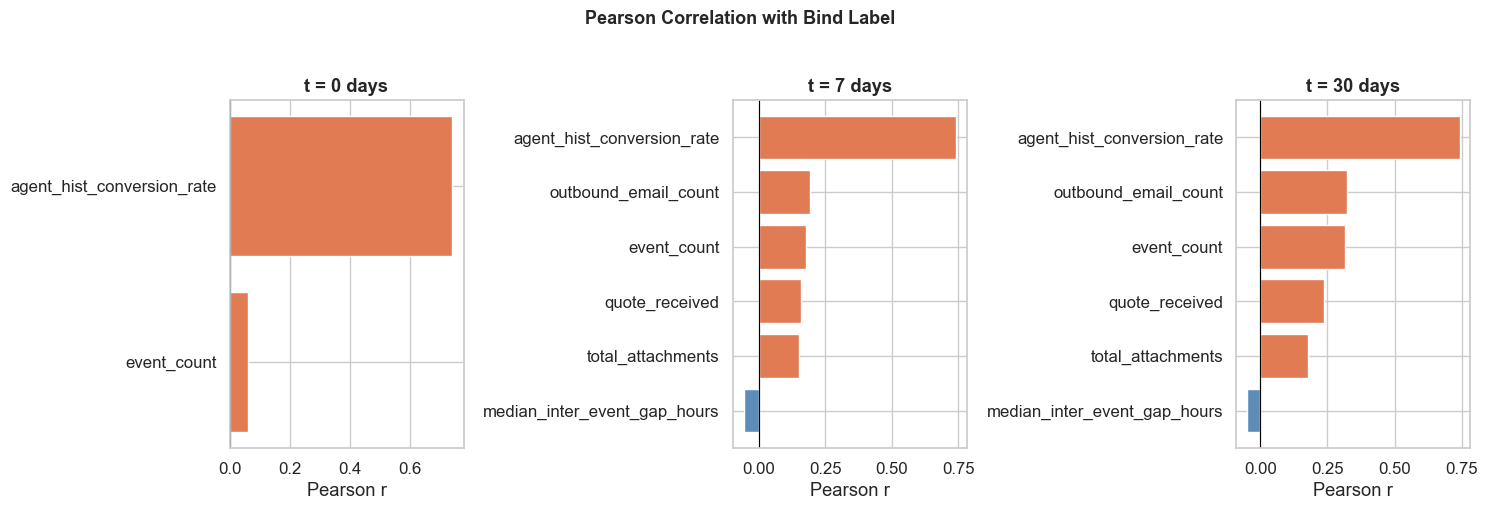

In [4]:
all_pearson = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, t in zip(axes, T_VALUES):
    fm = build_feature_matrix(t, subs, events)
    feat_cols = [c for c in fm.columns if c != 'label']
    corr = fm[feat_cols].corrwith(fm['label']).sort_values(key=abs, ascending=True)
    all_pearson[t] = corr

    colors = [COL_POS if v >= 0 else COL_NEG for v in corr.values]
    ax.barh(corr.index, corr.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f't = {t} days', fontweight='bold')
    ax.set_xlabel('Pearson r')

plt.suptitle('Pearson Correlation with Bind Label', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/predictive_significance/01_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Method 2: Mutual Information

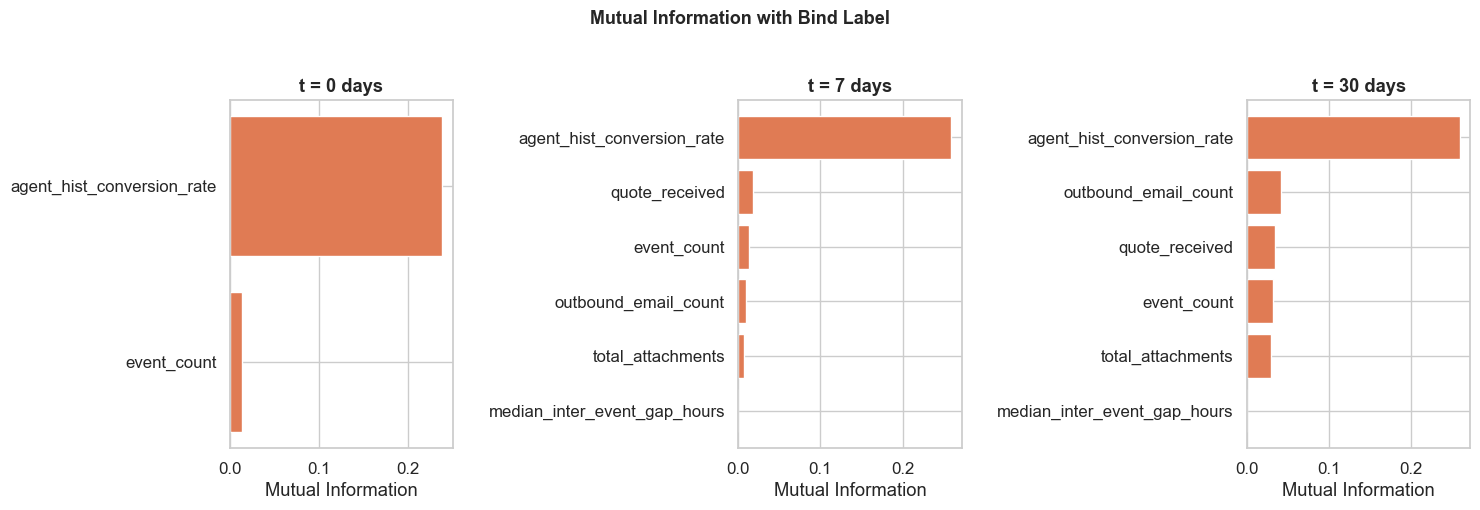

In [5]:
all_mi = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, t in zip(axes, T_VALUES):
    fm = build_feature_matrix(t, subs, events).dropna()
    feat_cols = [c for c in fm.columns if c != 'label']
    X, y = fm[feat_cols].values, fm['label'].values

    mi = mutual_info_classif(X, y, discrete_features=False, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi, index=feat_cols).sort_values(ascending=True)
    all_mi[t] = pd.Series(mi, index=feat_cols)

    ax.barh(mi_series.index, mi_series.values, color=COL_POS, edgecolor='white')
    ax.set_title(f't = {t} days', fontweight='bold')
    ax.set_xlabel('Mutual Information')

plt.suptitle('Mutual Information with Bind Label', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/predictive_significance/02_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Method 3: Random Forest Permutation Importance

Trained on a stratified 70/30 split with `class_weight='balanced'`.
Importance = mean decrease in ROC-AUC when a feature is randomly shuffled (n=30 repeats).
Error bars show ± 1 std across repeats.

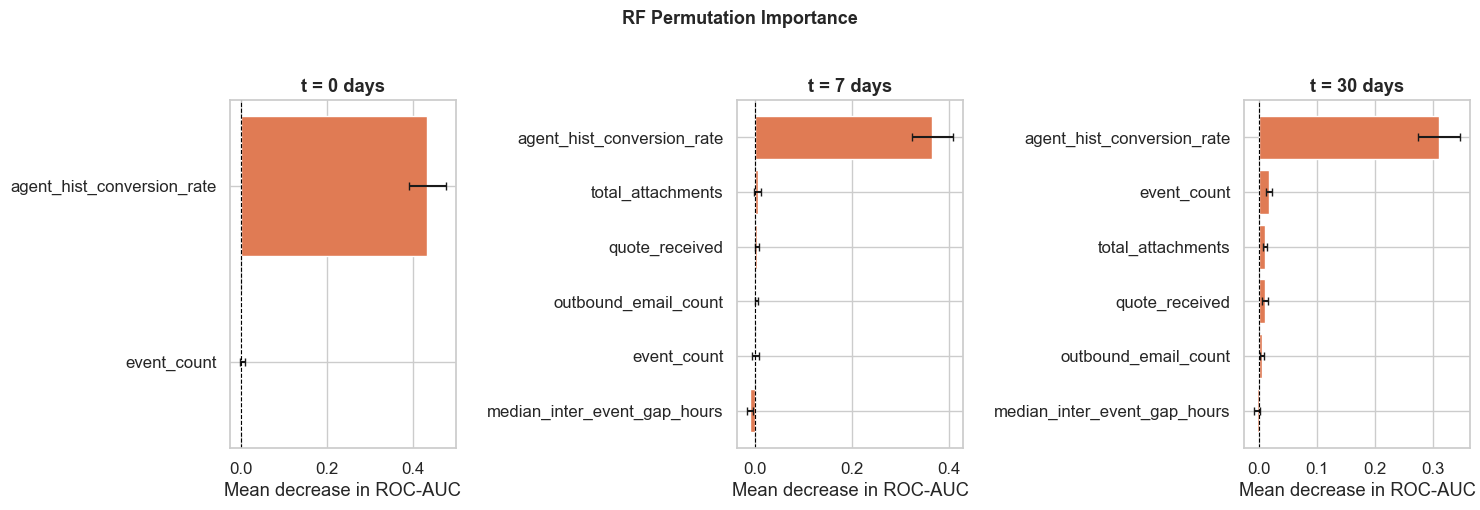

In [6]:
all_perm = {}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, t in zip(axes, T_VALUES):
    fm = build_feature_matrix(t, subs, events).dropna()
    feat_cols = [c for c in fm.columns if c != 'label']
    X, y = fm[feat_cols].values, fm['label'].values

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
    )
    rf = RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE
    )
    rf.fit(X_tr, y_tr)

    perm = permutation_importance(
        rf, X_te, y_te, n_repeats=30, scoring='roc_auc', random_state=RANDOM_STATE
    )
    imp_mean = pd.Series(perm.importances_mean, index=feat_cols)
    imp_std  = pd.Series(perm.importances_std,  index=feat_cols)
    all_perm[t] = imp_mean

    imp_sorted = imp_mean.sort_values(ascending=True)
    ax.barh(
        imp_sorted.index, imp_sorted.values,
        xerr=imp_std[imp_sorted.index].values,
        color=COL_POS, edgecolor='white', capsize=3
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f't = {t} days', fontweight='bold')
    ax.set_xlabel('Mean decrease in ROC-AUC')

plt.suptitle('RF Permutation Importance', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/predictive_significance/03_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary: Normalised Ranking Across Methods

Each method's scores are min-max normalised to [0, 1] within each `t`.
The heatmap shows the average normalised score — a consensus view of feature importance.

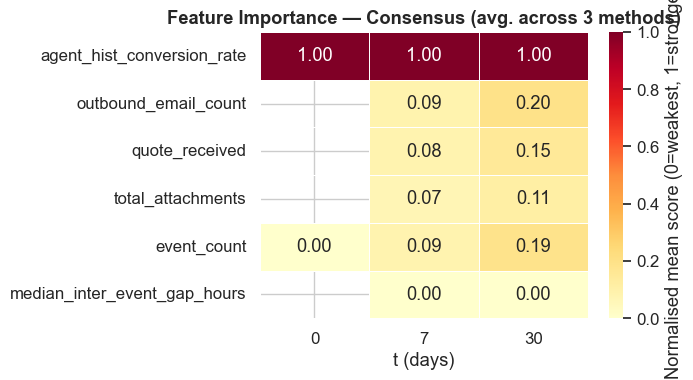


Ranking by mean score across all t:
feature
agent_hist_conversion_rate      1.000
outbound_email_count            0.142
quote_received                  0.117
total_attachments               0.092
event_count                     0.091
median_inter_event_gap_hours    0.000


In [7]:
ALL_FEATURES = [
    'agent_hist_conversion_rate', 'event_count', 'quote_received',
    'outbound_email_count', 'total_attachments', 'median_inter_event_gap_hours'
]

def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

rows = []
for t in T_VALUES:
    p_n  = minmax(all_pearson[t].abs())
    mi_n = minmax(all_mi[t])
    pm_n = minmax(all_perm[t])

    for feat in ALL_FEATURES:
        scores = [p_n.get(feat, np.nan), mi_n.get(feat, np.nan), pm_n.get(feat, np.nan)]
        rows.append({
            'feature':     feat,
            't':           t,
            'pearson':     p_n.get(feat, np.nan),
            'mutual_info': mi_n.get(feat, np.nan),
            'perm_imp':    pm_n.get(feat, np.nan),
            'mean_score':  np.nanmean(scores),
        })

summary = pd.DataFrame(rows)
pivot   = summary.pivot(index='feature', columns='t', values='mean_score')
pivot   = pivot.reindex(pivot.mean(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Normalised mean score (0=weakest, 1=strongest)'}
)
ax.set_title('Feature Importance — Consensus (avg. across 3 methods)', fontweight='bold')
ax.set_xlabel('t (days)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('output/predictive_significance/04_summary_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRanking by mean score across all t:')
print(pivot.mean(axis=1).sort_values(ascending=False).round(3).to_string())